# LeetCode Contest Cheating Detection
### Unsupervised Anomaly Detection | Rule-Based Scoring + Local Outlier Factor

**Goal:** Identify suspicious participants in LeetCode contests without any labelled data.  
**Method:** Domain-specific rule scoring combined with peer-group Local Outlier Factor (LOF).  
**Dataset:** Contest-level participation data across 3 contests (~19000 rows after cleaning).


## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [1]:
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parent.parent
print(ROOT_DIR)

C:\Users\karan\Desktop\lc_contest_cheater_detector


## 2. Load Data

We load the raw contest dataset. Each row represents one user's participation in one contest.


In [ ]:
df_raw = pd.read_csv(ROOT_DIR/'dataset'/"training_data_final.csv")


print(f"Combined shape: {df_raw.shape}")


df_raw = df_raw.drop_duplicates(subset='Username', keep='last')  # last = highest contest_id

print(f"After dedup (latest contest per user): {df_raw.shape}")

Combined shape: (19074, 20)
After dedup (latest contest per user): (19074, 20)


In [4]:
# Quick overview of data types and null counts
info = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'nulls': df_raw.isnull().sum(),
    'negatives': (df_raw.select_dtypes(include='number') < 0).sum()
})
print(info.to_string())

                 dtype  nulls  negatives
ContestCnt       int64      0        0.0
Country            str  10128        NaN
CurrConSolved    int64      0        0.0
CurrRating     float64     31        0.0
Easy             int64      0        0.0
GlobalRank       int64      0        0.0
Hard             int64      0        0.0
Medium           int64      0        0.0
PostViewCnt      int64      0        0.0
Profile_rank     int64      0        0.0
Rank             int64      0        0.0
Reputation       int64      0       43.0
Score            int64      0        0.0
Total_solved     int64      0        0.0
Username           str      0        NaN
active_days      int64      0        0.0
contest_id       int64      0        0.0
rating_first   float64     30        0.0
time_taken       int64      0        0.0
total_fail       int64      0        0.0


## 3. Data Cleaning

Before any analysis, we fix three data quality issues found during exploration.

| Issue | Count | Root Cause | Action |
|---|---|---|---|
| Null `rating_first` | 30 rows | New accounts with no prior rating | Drop rows |
| Null `currRating` | 31 rows | scraping error | Drop rows |


**Maximum dropped:** 61 rows (0.32% of data) — no meaningful loss.


In [5]:
df = df_raw.copy()

before = len(df)

# Issue 1: negative time_taken is physically impossible
df = df[df['time_taken'] > 0]

# Issue 2: null rating_first — account has no rating history, can't compute rating_jump
df = df[df['rating_first'].notna()]

df = df[df['CurrRating'].notna()]

#changing data type to int
df["CurrRating"] = df["CurrRating"].astype(int)
df["rating_first"] = df["rating_first"].astype(int)

df["contest_id"] = df["contest_id"].replace({
    1: 494,
    2: 495,
    3: 496
})

after = len(df)
print(f"Rows before cleaning : {before:,}")
print(f"Rows after  cleaning : {after:,}")
print(f"Rows dropped         : {before - after} ({(before-after)/before*100:.2f}%)")

Rows before cleaning : 19,074
Rows after  cleaning : 19,013
Rows dropped         : 61 (0.32%)


## 4. Exploratory Data Analysis (EDA)

We explore the distributions of key features to understand what 'normal' looks like — 
and where potential anomalies might hide.


In [6]:
df.describe().round(2)
#df.describe().round(2).to_csv("summary_stats.csv")

,Rank,Score,CurrConSolved,time_taken,total_fail,Profile_rank,PostViewCnt,Reputation,Total_solved,Easy,Medium,Hard,ContestCnt,CurrRating,rating_first,GlobalRank,active_days,contest_id
count,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00,19013.00
mean,5274.96,11.35,2.61,3147.08,1.38,885369.52,1017.71,15.72,442.45,156.04,236.49,49.92,27.23,1739.42,1508.51,150860.87,412.22,495.26
std,2864.74,3.60,0.66,1729.65,2.04,1275925.16,39209.42,403.62,411.20,128.23,232.57,78.47,40.73,198.81,84.84,132692.68,497.92,0.80
min,1.00,7.00,2.00,149.00,0.00,8.00,0.00,-11.00,2.00,0.00,0.00,0.00,1.00,1237.00,1355.00,17.00,0.00,494.00
25%,2850.00,9.00,2.00,1766.00,0.00,124382.00,0.00,0.00,160.00,63.00,72.00,8.00,7.00,1603.00,1447.00,55501.00,84.00,495.00
50%,5368.00,12.00,3.00,2802.00,1.00,344383.00,0.00,0.00,357.00,131.00,182.00,27.00,16.00,1704.00,1490.00,115003.00,246.00,495.00
75%,7789.00,14.00,3.00,4497.00,2.00,972274.00,12.00,1.00,602.00,217.00,325.00,60.00,32.00,1841.00,1550.00,207319.00,546.00,496.00
max,10000.00,20.00,4.00,14015.00,33.00,5000001.00,5175619.00,52559.00,3893.00,935.00,2037.00,921.00,632.00,3379.00,2483.00,856633.00,3507.00,496.00


#### What we can understand from this

- Most users solved **2–3 problems**, so the contest difficulty looks moderate  
- Some users solved all problems, but they are very few (top performers)  
- `time_taken` varies a lot — some users finished very quickly which looks a bit suspicious  
- Many users have participated in **only a few contests**, meaning lots of newcomers  
- Ratings range widely, so the contest includes **both beginners and experienced users**  
- Most users have **very low reputation**, meaning they don’t engage much on the platform  

**Overall:**  
The dataset looks realistic with a mix of beginners and experienced users.

### 4.1 Score & Problems Solved Distribution

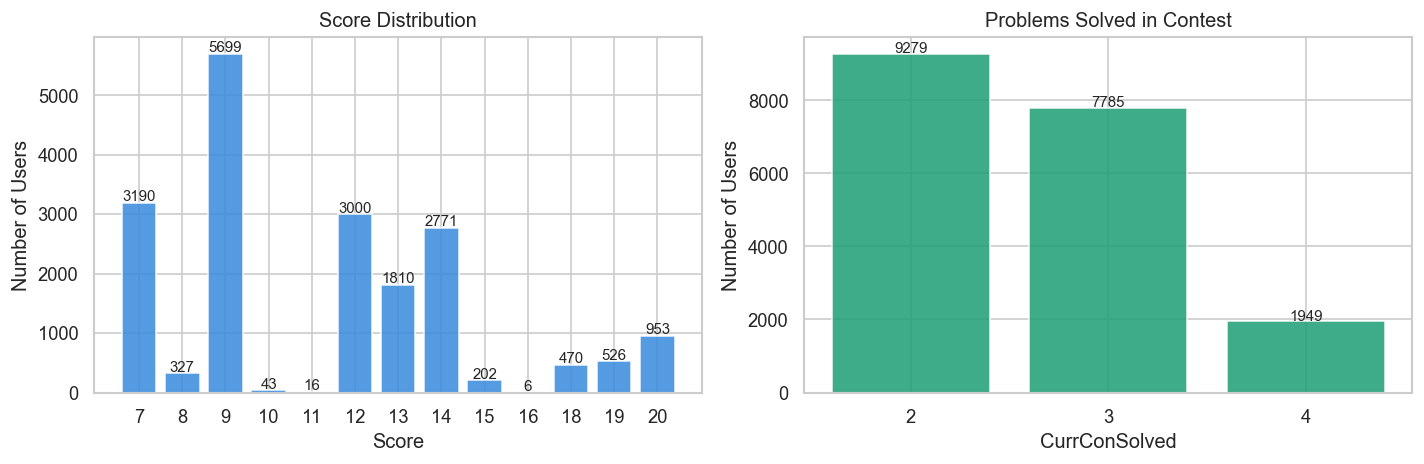

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #1 row and 2 columns,  width = 12, height = 4

# Score distribution
score_counts = df['Score'].value_counts().sort_index()
axes[0].bar(score_counts.index.astype(str), score_counts.values, color='#378ADD', alpha=0.85)
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(score_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

# CurrConSolved distribution
solved_counts = df['CurrConSolved'].value_counts().sort_index()
axes[1].bar(solved_counts.index.astype(str), solved_counts.values, color='#1D9E75', alpha=0.85)
axes[1].set_title('Problems Solved in Contest')
axes[1].set_xlabel('CurrConSolved')
axes[1].set_ylabel('Number of Users')
for i, v in enumerate(solved_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()



### 4.2 Time Taken Distribution

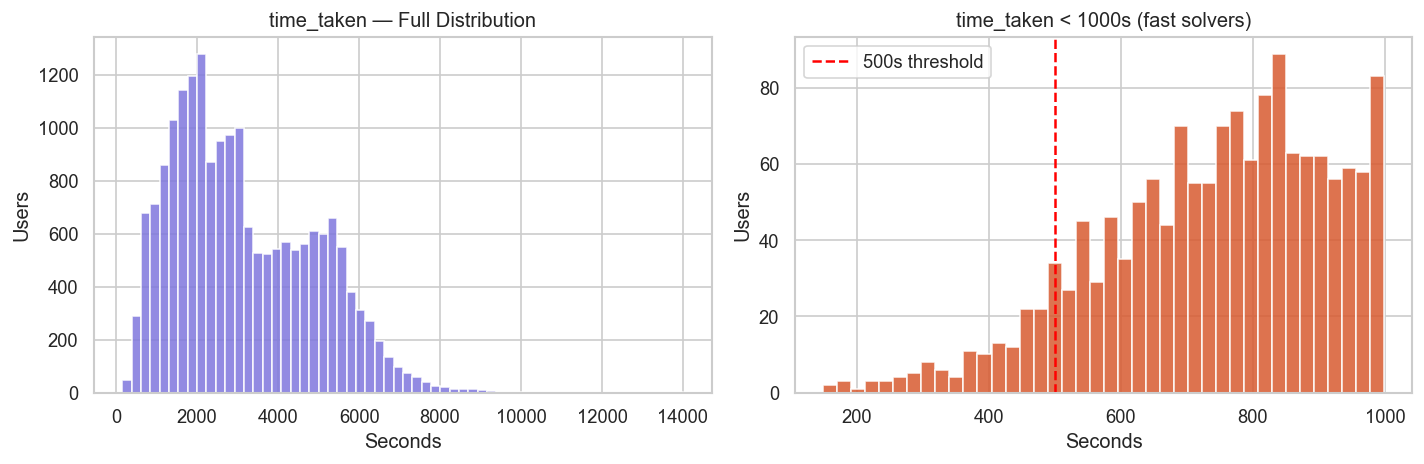

Users finishing in under 500 seconds: 148


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['time_taken'], bins=60, color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].set_title('time_taken — Full Distribution')
axes[0].set_xlabel('Seconds')
axes[0].set_ylabel('Users')

#fast solvers — potential cheaters
fast = df[df['time_taken'] < 1000]
axes[1].hist(fast['time_taken'], bins=40, color='#D85A30', alpha=0.85, edgecolor='white')
axes[1].set_title('time_taken < 1000s (fast solvers)')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Users')
axes[1].axvline(500, color='red', linestyle='--', linewidth=1.5, label='500s threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

n_fast = (df['time_taken'] < 500).sum()
print(f"Users finishing in under 500 seconds: {n_fast}")

Most users took a normal amount of time to finish the contest, mainly between 500–3000 seconds.  
A few users finished very quickly (under 500 seconds), which looks suspicious and should be checked.

### 4.3 Contest Experience & Rating Distribution

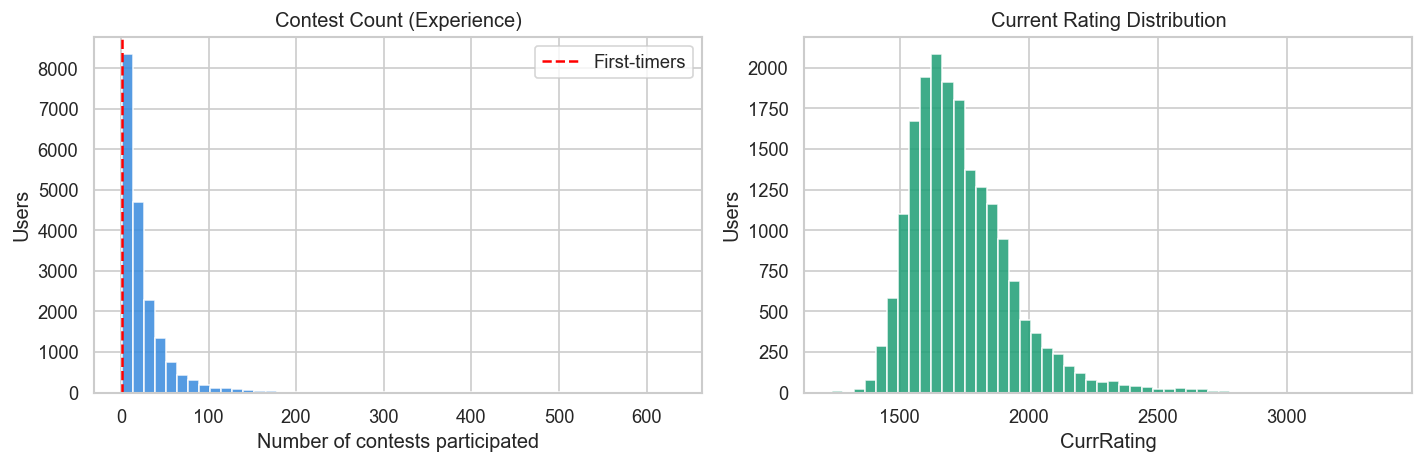

First-time contestants (ContestCnt=1): 732
Rating range: 1237 — 3379


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['ContestCnt'], bins=50, color='#378ADD', alpha=0.85, edgecolor='white')
axes[0].set_title('Contest Count (Experience)')
axes[0].set_xlabel('Number of contests participated')
axes[0].set_ylabel('Users')
axes[0].axvline(1, color='red', linestyle='--', linewidth=1.5, label='First-timers')
axes[0].legend()

axes[1].hist(df['CurrRating'], bins=50, color='#1D9E75', alpha=0.85, edgecolor='white')
axes[1].set_title('Current Rating Distribution')
axes[1].set_xlabel('CurrRating')
axes[1].set_ylabel('Users')

plt.tight_layout()
plt.show()

print(f"First-time contestants (ContestCnt=1): {(df['ContestCnt']==1).sum()}")
print(f"Rating range: {df['CurrRating'].min()} — {df['CurrRating'].max()}")

Most users have participated in only a small number of contests, showing many are relatively new, while a few users are highly experienced. The rating distribution is fairly wide, indicating a mix of beginners and experienced users in the contest.

### 4.4 Correlation Heatmap

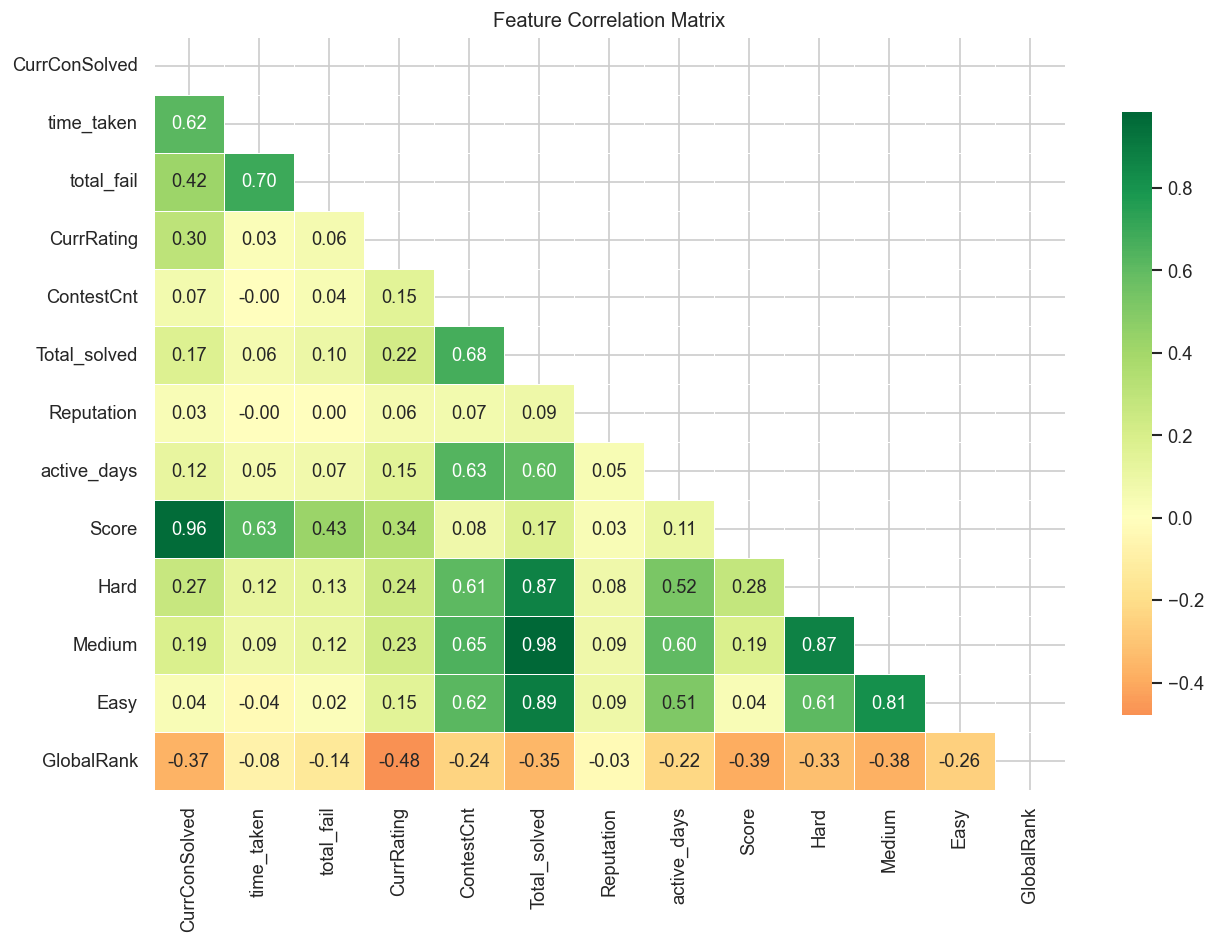

High correlation pairs (>0.85) — candidates for dropping:
  CurrConSolved        <-> Score                : 0.962
  Total_solved         <-> Hard                 : 0.870
  Total_solved         <-> Medium               : 0.984
  Total_solved         <-> Easy                 : 0.889
  Hard                 <-> Medium               : 0.865


In [10]:
num_cols = ['CurrConSolved', 'time_taken', 'total_fail', 'CurrRating',
            'ContestCnt', 'Total_solved', 'Reputation', 'active_days',
            'Score', 'Hard', 'Medium', 'Easy', 'GlobalRank']

corr = df[num_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("High correlation pairs (>0.85) — candidates for dropping:")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = abs(corr.iloc[i, j])
        if v > 0.85:
            print(f"  {corr.columns[i]:20s} <-> {corr.columns[j]:20s} : {v:.3f}")

Score is highly related to problems solved, which is expected since solving more problems gives higher scores.  
Easy, Medium, and Hard solved are also strongly related to total solved, while GlobalRank shows negative correlation — better performance leads to better rank.

## 5. Feature Selection

### Why we drop certain features

| Feature | Decision | Reason |
|---|---|---|
| `Score` | Drop | r = 0.96 with CurrConSolved — perfect duplicate |
| `Easy`, `Medium` | Drop | r > 0.88 with Total_solved — redundant |
| `Hard` | Drop | Captured better by engineered `hard_ratio` |
| `GlobalRank` | Drop | r = 0.78 with CurrRating — same information |
| `Profile_rank` | Drop | Variance = 1.63 trillion — extremely noisy |
| `PostViewCnt` | Drop | Community metric, unrelated to cheating |
| `Country` | Drop | 53% missing + introduces geographic bias |
| `rating_first` | Drop | Superseded by engineered `rating_jump` |
| `Rank` | Drop | Derived from score — adds no independent info |
| `Username` | Drop | Identifier, not a feature |

### Why we keep these features

| Feature | Why it matters |
|---|---|
| `CurrConSolved` | Core: how many problems solved in contest |
| `time_taken` | Key cheat signal: cheaters finish abnormally fast |
| `total_fail` | Zero fails + all solved = suspicious pattern |
| `CurrRating` | Skill level — used for peer group comparison |
| `ContestCnt` | First-timers scoring high is a red flag |
| `Total_solved` | Profile consistency check |
| `Reputation` | Fair users accumulate reputation over time |
| `active_days` | Platform engagement signal |


In [11]:
# Features to keep (raw)
KEEP = ['CurrConSolved', 'time_taken', 'total_fail', 'CurrRating',
        'ContestCnt', 'Total_solved', 'Reputation', 'active_days', 'contest_id']

df_clean = df[['Username'] + KEEP + ['rating_first', 'Hard', 'Rank', 'Score']].copy()
print("Working dataframe shape:", df_clean.shape)
df_clean.head()

Working dataframe shape: (19013, 14)


,Username,CurrConSolved,time_taken,total_fail,CurrRating,ContestCnt,Total_solved,Reputation,active_days,contest_id,rating_first,Hard,Rank,Score
0,ProD24,3,5235,0,1708,7,154,0,280,494,1548,9,7650,12
1,vanshika1594,3,3369,0,1542,2,349,0,7,494,1615,44,5011,12
2,yourstherapist01,3,3736,0,1742,6,187,0,21,494,1606,19,5652,12
3,Vikram_Dhatarwal,3,2606,0,1546,16,385,0,315,494,1414,22,3635,12
4,74OVxXCwcT,3,5651,1,1573,1,4,0,0,494,1574,0,8096,12


## 6. Feature Engineering

Raw features alone don't capture the full picture. We derive four new features that 
are specifically designed to surface cheating patterns.

| Engineered Feature | Formula | What it catches |
|---|---|---|
| `rating_jump` | `CurrRating - rating_first` | 0 = never had a rating before (bot/fake account) |
| `score_per_time` | `CurrConSolved / time_taken` | Extreme efficiency = solved too fast |
| `hard_ratio` | `Hard / (Total_solved + 1)` | Skill composition — hard to fake |
| `solved_per_contest` | `Total_solved / (ContestCnt + 1)` | Low practice + high contest rank = suspicious |


In [12]:
# Engineer new features
df_clean['rating_jump']        = df['CurrRating'] - df['rating_first']
df_clean['score_per_time']     = df_clean['CurrConSolved'] / df_clean['time_taken'].clip(lower=1)
df_clean['hard_ratio']         = df_clean['Hard'] / (df_clean['Total_solved'] + 1)
df_clean['solved_per_contest'] = df_clean['Total_solved'] / (df_clean['ContestCnt'] + 1)

# Final feature list for modelling
MODEL_FEATURES = KEEP + ['rating_jump', 'score_per_time', 'hard_ratio', 'solved_per_contest']

print("Final features for model:")
for f in MODEL_FEATURES:
    print(f"  - {f}")

df_clean[MODEL_FEATURES].describe().round(3)

Final features for model:
  - CurrConSolved
  - time_taken
  - total_fail
  - CurrRating
  - ContestCnt
  - Total_solved
  - Reputation
  - active_days
  - contest_id
  - rating_jump
  - score_per_time
  - hard_ratio
  - solved_per_contest


,CurrConSolved,time_taken,total_fail,CurrRating,ContestCnt,Total_solved,Reputation,active_days,contest_id,rating_jump,score_per_time,hard_ratio,solved_per_contest
count,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000,19013.000
mean,2.614,3147.082,1.380,1739.424,27.228,442.449,15.724,412.216,495.264,230.915,0.001,0.094,24.888
std,0.665,1729.651,2.044,198.809,40.726,411.198,403.623,497.921,0.799,198.938,0.001,0.067,30.742
min,2.000,149.000,0.000,1237.000,1.000,2.000,-11.000,0.000,494.000,-391.000,0.000,0.000,0.297
25%,2.000,1766.000,0.000,1603.000,7.000,160.000,0.000,84.000,495.000,93.000,0.001,0.044,9.123
50%,3.000,2802.000,1.000,1704.000,16.000,357.000,0.000,246.000,495.000,201.000,0.001,0.086,17.197
75%,3.000,4497.000,2.000,1841.000,32.000,602.000,1.000,546.000,496.000,334.000,0.001,0.130,29.852
max,4.000,14015.000,33.000,3379.000,632.000,3893.000,52559.000,3507.000,496.000,1654.000,0.014,0.966,960.250


### 6.1 Visualising Engineered Features

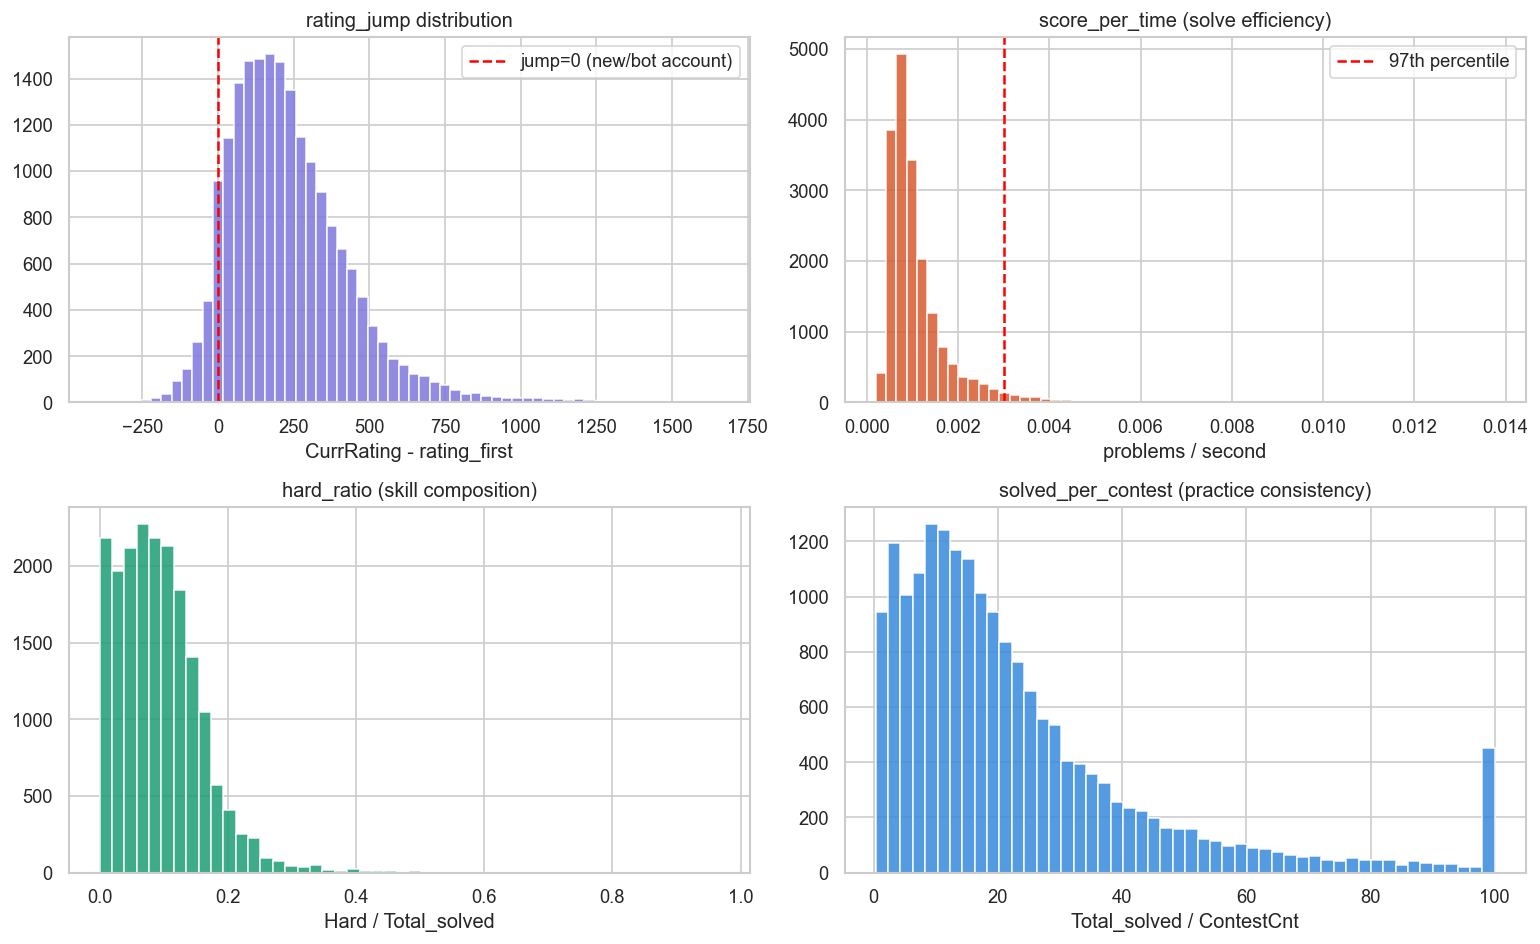

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].hist(df_clean['rating_jump'], bins=60, color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='jump=0 (new/bot account)')
axes[0,0].set_title('rating_jump distribution')
axes[0,0].set_xlabel('CurrRating - rating_first')
axes[0,0].legend()

axes[0,1].hist(df_clean['score_per_time'], bins=60, color='#D85A30', alpha=0.85, edgecolor='white')
axes[0,1].axvline(df_clean['score_per_time'].quantile(0.97), color='red',
                   linestyle='--', linewidth=1.5, label='97th percentile')
axes[0,1].set_title('score_per_time (solve efficiency)')
axes[0,1].set_xlabel('problems / second')
axes[0,1].legend()

axes[1,0].hist(df_clean['hard_ratio'], bins=50, color='#1D9E75', alpha=0.85, edgecolor='white')
axes[1,0].set_title('hard_ratio (skill composition)')
axes[1,0].set_xlabel('Hard / Total_solved')

axes[1,1].hist(df_clean['solved_per_contest'].clip(upper=100), bins=50,
               color='#378ADD', alpha=0.85, edgecolor='white')
axes[1,1].set_title('solved_per_contest (practice consistency)')
axes[1,1].set_xlabel('Total_solved / ContestCnt')

plt.tight_layout()
plt.show()

- Most users show positive rating growth, with only a few having little or no improvement  
- Solve efficiency is mostly low, but a small group of very fast solvers stands out  
- Hard problem ratio is low for most users, meaning fewer hard problems are solved  
- Solved per contest varies widely, showing differences in user practice consistency

## 7. Why Not Isolation Forest?

Isolation Forest is a popular anomaly detection algorithm, but it fails here for a specific reason:

**It detects statistical outliers — not cheaters.**

Elite competitive programmers are also statistical outliers:
- Very high rating
- Very fast solve times
- Large rating jumps per contest

So Isolation Forest flags legitimate top performers alongside actual cheaters. We verified 
this by running it and manually checking the flagged users — most were fair.

### Our approach instead: Rule-Based Scoring + Peer-Group LOF

**Rule-based scoring** encodes domain knowledge about *what cheating looks like* specifically.

**Local Outlier Factor (LOF)** compares each user only to others in the *same rating bucket* 
(peer group). This means an elite user is only compared to other elites — if they look 
anomalous among their own peers, that's a real signal.


In [14]:
# Demonstrate the Isolation Forest problem
from sklearn.ensemble import IsolationForest

X = df_clean[MODEL_FEATURES].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(X_scaled)

df_clean['iso_flag'] = (iso_labels == -1).astype(int)

# Show what IF flags
iso_flagged = df_clean[df_clean['iso_flag'] == 1].sort_values('CurrRating', ascending=False)
print(f"Isolation Forest flagged: {df_clean['iso_flag'].sum()} users")
print("\nTop 10 flagged by IF (sorted by rating — these are likely FAIR elite users):")
print(iso_flagged[['Username','CurrConSolved','time_taken','CurrRating',
                    'ContestCnt','Total_solved']].head(10).to_string(index=False))

Isolation Forest flagged: 951 users

Top 10 flagged by IF (sorted by rating — these are likely FAIR elite users):
     Username  CurrConSolved  time_taken  CurrRating  ContestCnt  Total_solved
 endlesscheng              4         780        3379         277          1179
ayushkumar980              4         491        3321          16           106
       dnialh              4        1846        3216          64           259
    PushmeetK              4         805        3109           5            22
    25BCE5532              4        1052        2973           7            17
  la_castille              4        1050        2972          24          1720
    Indomitus              4         580        2917          69          1532
 anshika4-dev              4         829        2917          19           894
      jacobj2              4        1161        2890         134          1815
    24CS01005              2        1036        2885          29           448


## 8. Rule-Based Suspicion Scoring

Each rule is grounded in a specific cheating pattern observed in the data.  
Rules are weighted by how strong the signal is.


In [15]:
print("\nThreshold Analysis Report\n")

thresholds = {
    "Active days (Bottom 20%)": df_clean['active_days'].quantile(0.20),
    "Score (Top 20%)": df_clean['Score'].quantile(0.80),
    # "Score per time (Top 3%)": df_clean['score_per_time'].quantile(0.90),
    "Very large rating jump (Top 10%)": df_clean['rating_jump'].quantile(0.90),
    "High rating users (Top 10%)": df_clean['CurrRating'].quantile(0.90),
    "Low solved count (Bottom 20%)": df_clean['Total_solved'].quantile(0.20),
    "Top contest ranks (Top 5%)": df_clean['Rank'].quantile(0.05),
}

for k, v in thresholds.items():
    print(f"{k:40s} : {v:.2f}")


Threshold Analysis Report

Active days (Bottom 20%)                 : 64.00
Score (Top 20%)                          : 14.00
Very large rating jump (Top 10%)         : 479.00
High rating users (Top 10%)              : 1980.80
Low solved count (Bottom 20%)            : 118.00
Top contest ranks (Top 5%)               : 618.60


In [16]:
def rule_low_active(df): #Near-zero active time with high score
    return (df['active_days'] < 50) & (df['Score'] >= 10)

def rule_new_account_top_rank(df): #new user high rank
    return (df["ContestCnt"] <= 5) & (df["Rank"] < 200)

def rule_perfect_solve(df):
    return (df['total_fail'] == 0) & (df['Score'] >= 15) & (df['ContestCnt'] <= 5)

def rule_weak_profile(df): #Weak profile but top contest rank
    return (df['Total_solved'] < 200) & (df['Rank'] < 200)

def rule_low_solved_high_rating(df): #Low solved count but high rating
    return (df['Total_solved'] < 100) & (df['CurrRating'] > 1900)

def rule_zero_rating_jump(df):
    return (df['rating_jump'] == 0) & (df['CurrRating'] > 1500)

def rule_ghost_profile(df):
    return (df['Total_solved'] < 50) & (df['Rank'] < 5000)

# def rule_extreme_efficiency(df, threshold): #Extreme score-per-active efficiency (top 3%)
#     return df['score_per_time'] > threshold

# efficiency_threshold = df_clean['score_per_time'].quantile(0.97)
RULES = [
    {'name': 'Near-zero active time with high score',  'func': rule_low_active,              'weight': 3},
    {'name': 'new user high rank',                     'func': rule_new_account_top_rank,    'weight': 3},
    {'name': 'Perfect solve',                          'func': rule_perfect_solve,           'weight': 2},
    {'name': 'Weak profile',                           'func': rule_weak_profile,            'weight': 2},
    {'name': 'Low solved high rating',                 'func': rule_low_solved_high_rating,  'weight': 2},
    # {'name': 'Extreme efficiency',                     'func': rule_extreme_efficiency, 'weight': 2, 'threshold': efficiency_threshold},
    {'name': 'Zero rating jump high rating',           'func': rule_zero_rating_jump,        'weight': 3},  # NEW
    {'name': 'Ghost profile high rank',                'func': rule_ghost_profile,           'weight': 2},  # NEW
]

# Apply rules
sus = np.zeros(len(df_clean))
triggered = [''] * len(df_clean)

for rule in RULES:
    mask = rule['func'](df_clean).values

    sus[mask] += rule['weight']

    for i in np.where(mask)[0]:
        triggered[i] += rule['name'] + ' | '

    print(f"[{mask.sum():4d} users] {rule['name']}")

df_clean['rule_score'] = sus
df_clean['triggered_rules'] = [t.rstrip(' | ') for t in triggered]

print(f"\nMax rule score: {df_clean['rule_score'].max()}")
print(f"Users with rule_score > 0: {(df_clean['rule_score'] > 0).sum()}")

[1544 users] Near-zero active time with high score
[  87 users] new user high rank
[ 124 users] Perfect solve
[ 123 users] Weak profile
[ 478 users] Low solved high rating
[ 167 users] Zero rating jump high rating
[1017 users] Ghost profile high rank

Max rule score: 17.0
Users with rule_score > 0: 2386


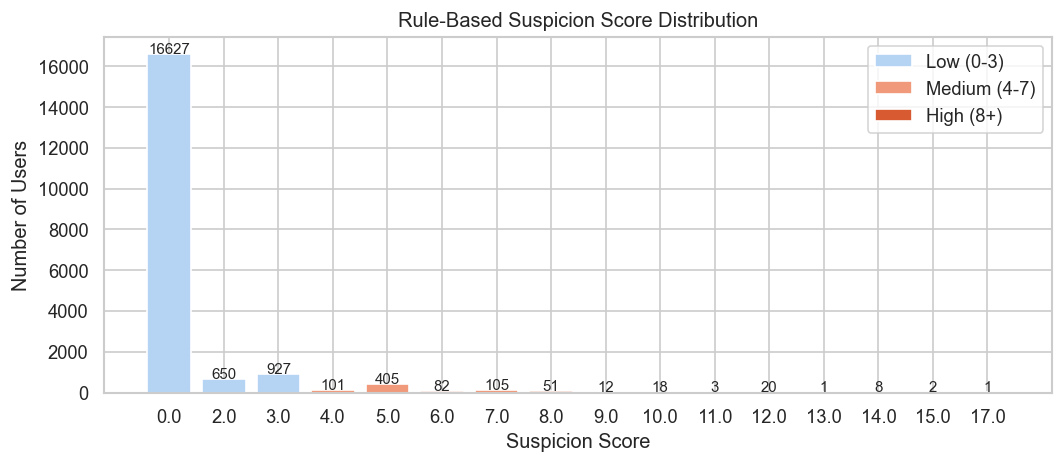

In [17]:
# Visualise rule score distribution
fig, ax = plt.subplots(figsize=(9, 4))
score_counts = df_clean['rule_score'].value_counts().sort_index()
colors = ['#B5D4F4' if s < 4 else '#F0997B' if s < 8 else '#D85A30'
          for s in score_counts.index]
ax.bar(score_counts.index.astype(str), score_counts.values, color=colors, edgecolor='white')
ax.set_title('Rule-Based Suspicion Score Distribution')
ax.set_xlabel('Suspicion Score')
ax.set_ylabel('Number of Users')
for i, (s, v) in enumerate(zip(score_counts.index, score_counts.values)):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#B5D4F4', label='Low (0-3)'),
                   Patch(facecolor='#F0997B', label='Medium (4-7)'),
                   Patch(facecolor='#D85A30', label='High (8+)')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## 9. Local Outlier Factor (LOF) — Peer Group Comparison

### Why peer groups?

A rating-3000 user solving all 4 problems in 400 seconds is normal for their skill level.  
A rating-1500 user doing the same is extremely suspicious.

By splitting users into rating buckets and running LOF within each bucket, we ensure 
every user is only compared to their peers — not the entire population.

### How LOF works

LOF assigns each point a score based on how isolated it is relative to its k nearest 
neighbours. A score near 1.0 = normal. Score > 1.5 = outlier in its local neighbourhood.


In [18]:
RATING_BINS   = [0, 1600, 1800, 2000, 2200, 5000]
RATING_LABELS = ['D (<1600)', 'C (1600-1800)', 'B (1800-2000)', 'A (2000-2200)', 'S (2200+)']

df_clean['rating_bucket'] = pd.cut(df_clean['CurrRating'],
                                    bins=RATING_BINS, labels=RATING_LABELS)

LOF_FEATURES = ['CurrConSolved', 'time_taken', 'total_fail',
                'score_per_time', 'hard_ratio']

lof_models = {} #for storing the model

lof_scores = np.zeros(len(df_clean))

for bucket in RATING_LABELS:
    mask = (df_clean['rating_bucket'] == bucket).values
    group = df_clean.loc[mask, LOF_FEATURES].fillna(0)
    n = mask.sum()
    if n < 10: #Skip Small Groups because LOF needs enough data to detect anomalies.
        print(f"  [SKIP] {bucket}: only {n} users")
        continue

    k = min(20, n - 1)               #Feature Scaling Makes features comparable.
    scaler_lof = StandardScaler()
    X_lof = scaler_lof.fit_transform(group)

     # IMPORTANT → novelty=True for prediction later
    lof = LocalOutlierFactor(
        n_neighbors=k,
        contamination=0.2,
        novelty=True
    )

    lof.fit(X_lof)
    scores = -lof.score_samples(X_lof)
    lof_scores[mask] = scores

    #STORE MODEL
    lof_models[bucket] = {
        "scaler": scaler_lof,
        "lof": lof,
        "min": scores.min(),
        "max": scores.max()
    }

    n_outliers = int((scores > 1.5).sum())
    print(f"  [{bucket}]  {n:5d} users | {n_outliers:3d} LOF outliers (score > 1.5)")

df_clean['lof_score'] = lof_scores

lo, hi = lof_scores.min(), lof_scores.max()
df_clean['lof_normalized'] = ((lof_scores - lo) / (hi - lo + 1e-9)) * 3
print(f"\nLOF score range: {lo:.3f} — {hi:.3f}")

  [D (<1600)]   4660 users |  73 LOF outliers (score > 1.5)
  [C (1600-1800)]   8402 users | 116 LOF outliers (score > 1.5)
  [B (1800-2000)]   4250 users |  65 LOF outliers (score > 1.5)
  [A (2000-2200)]   1164 users |  45 LOF outliers (score > 1.5)
  [S (2200+)]    537 users |  23 LOF outliers (score > 1.5)

LOF score range: 0.942 — 4.071


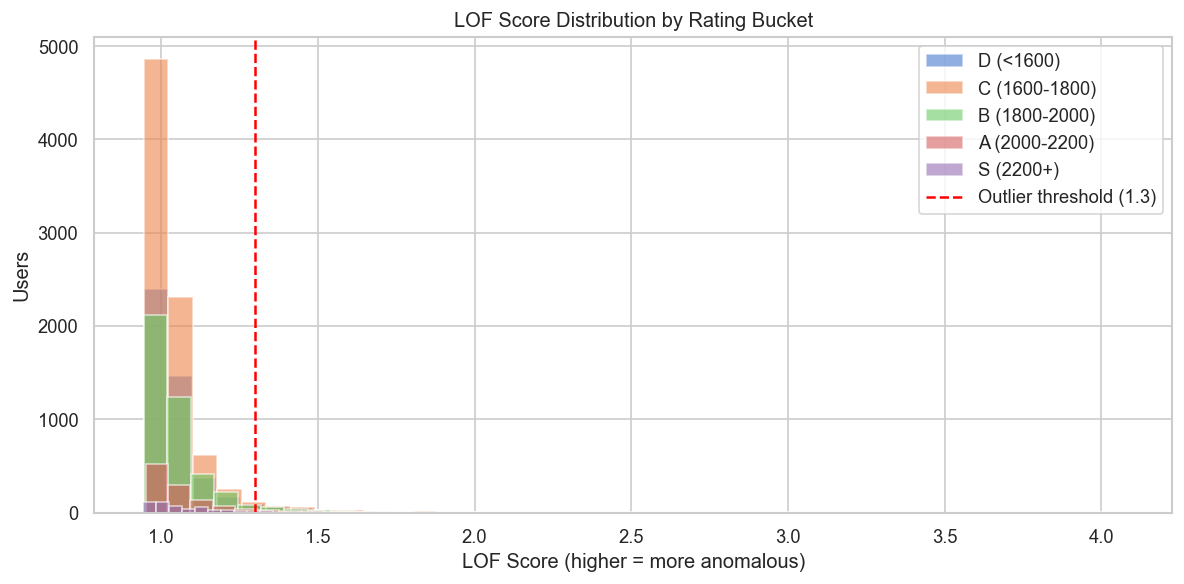

In [38]:
# LOF score distribution per bucket
fig, ax = plt.subplots(figsize=(10, 5))
for bucket in RATING_LABELS:
    subset = df_clean[df_clean['rating_bucket'] == bucket]['lof_score']
    if len(subset) > 0:
        ax.hist(subset, bins=40, alpha=0.6, label=bucket)

ax.axvline(1.3, color='red', linestyle='--', linewidth=1.5, label='Outlier threshold (1.3)')
ax.set_title('LOF Score Distribution by Rating Bucket')
ax.set_xlabel('LOF Score (higher = more anomalous)')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Combining Scores → Final Suspicion Score

The final score combines:
- **Rule score** (0–14): domain knowledge, weighted flags
- **LOF normalized** (0–3): statistical anomaly within peer group

Users in the top 10% by final score are flagged as suspicious.


In [20]:
df_clean['final_score'] = df_clean['rule_score'] + df_clean['lof_normalized']

THRESHOLD_PERCENTILE = 0.80
threshold = df_clean['final_score'].quantile(THRESHOLD_PERCENTILE)
df_clean['suspicious'] = df_clean['final_score'] >= threshold

print(f"Threshold (top 20%): {threshold:.3f}")
print(f"Flagged as suspicious : {df_clean['suspicious'].sum():,}")
print(f"High confidence (≥5)  : {(df_clean['final_score'] >= 5).sum():,}")
print(f"Clean users           : {(~df_clean['suspicious']).sum():,}")

Threshold (top 20%): 0.221
Flagged as suspicious : 3,803
High confidence (≥5)  : 710
Clean users           : 15,210


## 11. Results Visualisation

### 11.1 Final Score Distribution

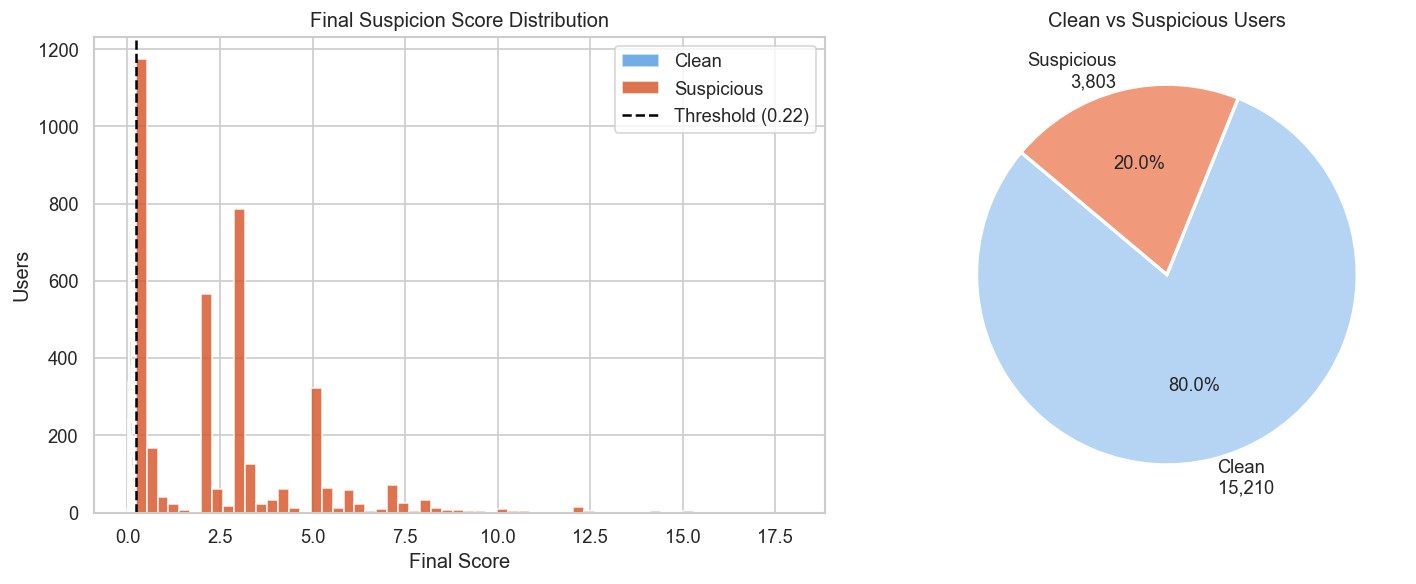

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df_clean[~df_clean['suspicious']]['final_score'],
             bins=60, alpha=0.7, color='#378ADD', label='Clean')
axes[0].hist(df_clean[df_clean['suspicious']]['final_score'],
             bins=60, alpha=0.85, color='#D85A30', label='Suspicious')
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold ({threshold:.2f})')
axes[0].set_title('Final Suspicion Score Distribution')
axes[0].set_xlabel('Final Score')
axes[0].set_ylabel('Users')
axes[0].legend()

# Pie chart
sus_count = df_clean['suspicious'].sum()
clean_count = len(df_clean) - sus_count
axes[1].pie([clean_count, sus_count],
            labels=[f'Clean\n{clean_count:,}', f'Suspicious\n{sus_count:,}'],
            colors=['#B5D4F4', '#F0997B'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Clean vs Suspicious Users')

plt.tight_layout()
plt.show()

### 11.2 Key Feature Comparison: Clean vs Suspicious

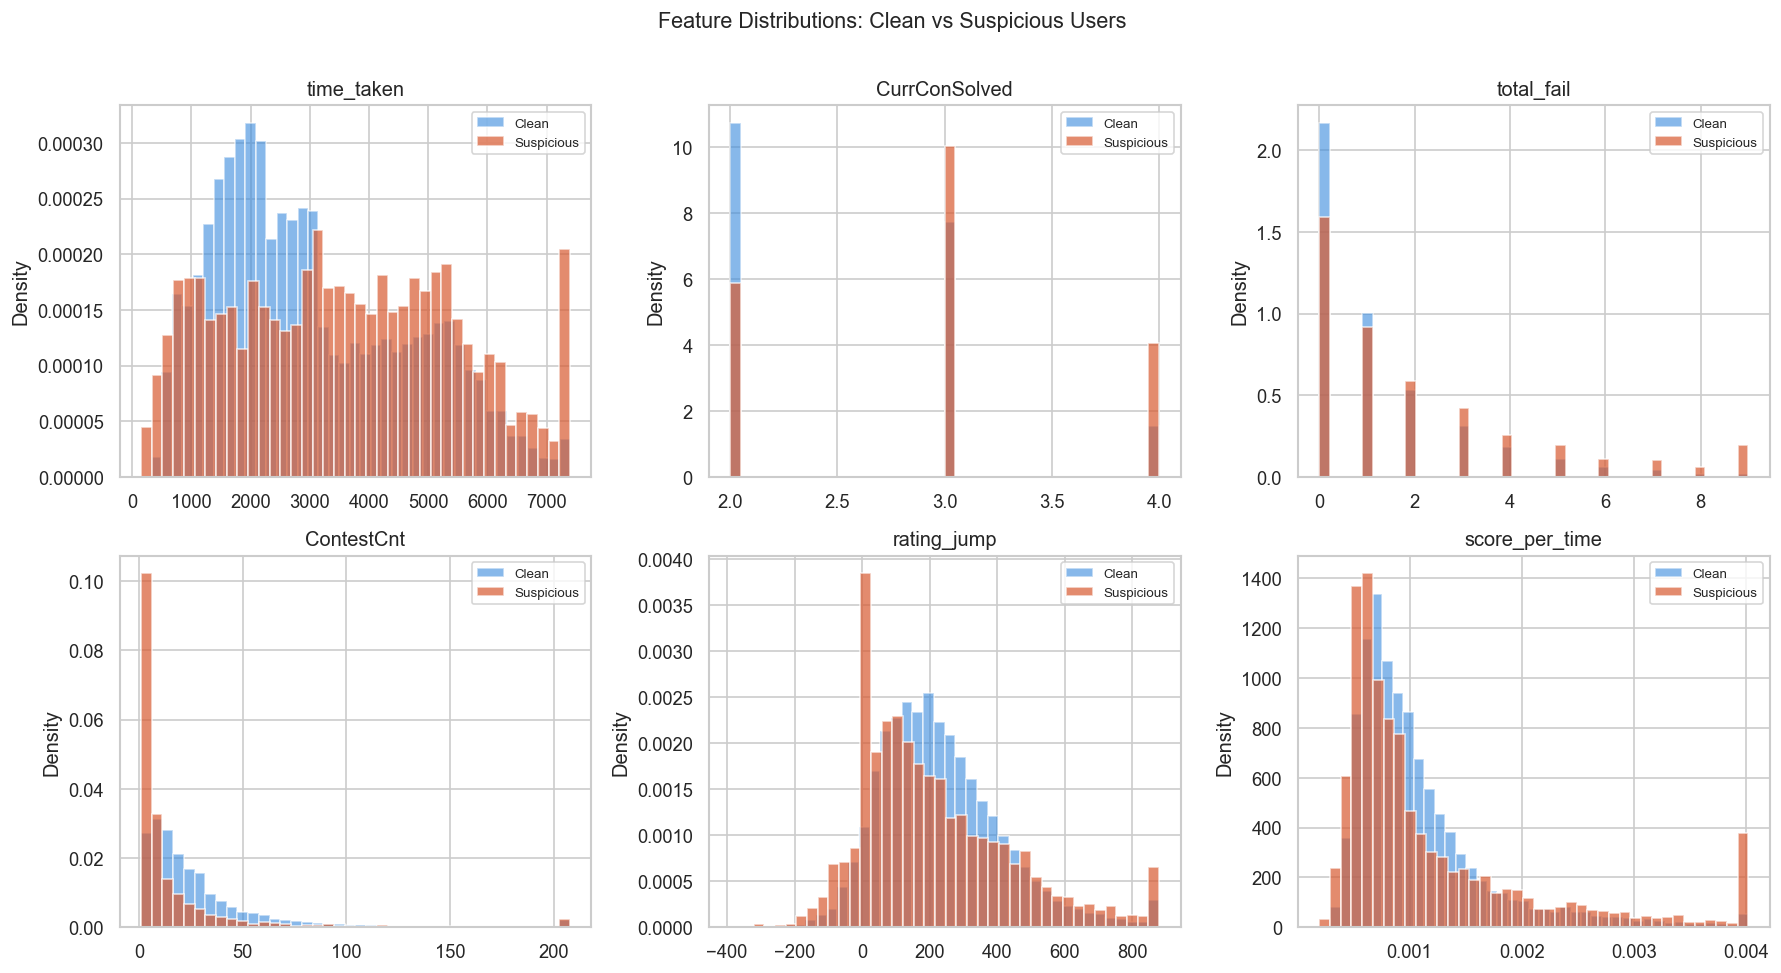

In [22]:
features_to_plot = ['time_taken', 'CurrConSolved', 'total_fail',
                    'ContestCnt', 'rating_jump', 'score_per_time']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    clean_vals  = df_clean[~df_clean['suspicious']][feat].clip(
                    upper=df_clean[feat].quantile(0.99))
    sus_vals    = df_clean[df_clean['suspicious']][feat].clip(
                    upper=df_clean[feat].quantile(0.99))

    axes[i].hist(clean_vals, bins=40, alpha=0.6, color='#378ADD', label='Clean', density=True)
    axes[i].hist(sus_vals,   bins=40, alpha=0.7, color='#D85A30', label='Suspicious', density=True)
    axes[i].set_title(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Clean vs Suspicious Users', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 11.4 Rule Trigger Breakdown

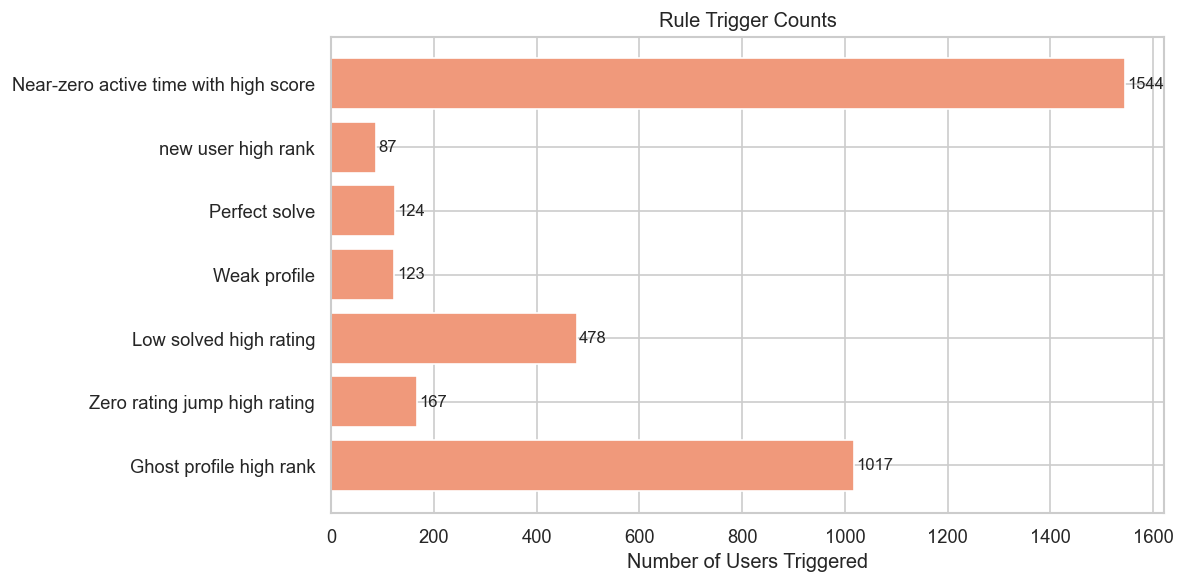

In [23]:
rule_names = [r['name'] for r in RULES]
rule_counts = []
for r in RULES:
   
    count = int(r['func'](df_clean).sum())
    rule_counts.append(count)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rule_names, rule_counts, color='#F0997B', edgecolor='white')
ax.set_xlabel('Number of Users Triggered')
ax.set_title('Rule Trigger Counts')
for bar, count in zip(bars, rule_counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 11.5 Top 20 Most Suspicious Users

In [24]:
top_suspicious = (df_clean[df_clean['suspicious']]
                  .sort_values('final_score', ascending=False)
                  .head(20))

display_cols = ['Username', 'Rank', 'CurrConSolved', 'time_taken',
                'total_fail', 'ContestCnt', 'Total_solved',
                'CurrRating', 'rating_jump', 'final_score', 'triggered_rules', "contest_id"]

print("TOP 20 MOST SUSPICIOUS USERS")
print("=" * 80)
print(top_suspicious[display_cols].to_string(index=False))

TOP 20 MOST SUSPICIOUS USERS
          Username  Rank  CurrConSolved  time_taken  total_fail  ContestCnt  Total_solved  CurrRating  rating_jump  final_score                                                                                                                                                             triggered_rules  contest_id
       hfgdnnvnxfg     4              4         551           0           1            28        2047            0    17.955796 Near-zero active time with high score | new user high rank | Perfect solve | Weak profile | Low solved high rating | Zero rating jump high rating | Ghost profile high rank         494
         himank028     6              4         491           0           3            13        2188          128    15.291080                                Near-zero active time with high score | new user high rank | Perfect solve | Weak profile | Low solved high rating | Ghost profile high rank         495
        SArJZB8AUf   109           

## 12. Export Results

In [ ]:
output_cols = ['Username', 'Rank', 'CurrConSolved', 'time_taken', 'total_fail',
               'ContestCnt', 'Total_solved', 'CurrRating', 'rating_jump',
               'Reputation', 'active_days', 'rule_score', 'lof_normalized',
               'final_score', 'suspicious', 'rating_bucket', 'triggered_rules']

results = df_clean[output_cols].sort_values('final_score', ascending=False)
results.to_csv(ROOT_DIR/'model'/'model_v1'/'cheat_detection_results.csv', index=False)

print(f"Saved {len(results):,} rows to cheat_detection_results.csv")
print(f"\nSummary:")
print(f"  Total users   : {len(results):,}")
print(f"  Suspicious    : {results['suspicious'].sum():,}")
print(f"  Clean         : {(~results['suspicious']).sum():,}")

Saved 19,013 rows to cheat_detection_results.csv

Summary:
  Total users   : 19,013
  Suspicious    : 3,803
  Clean         : 15,210


## 13. Saving the Model

In [ ]:
import joblib

joblib.dump({
    "lof_models": lof_models,
    "LOF_FEATURES": LOF_FEATURES,
    "RATING_BINS": RATING_BINS,
    "RATING_LABELS": RATING_LABELS,
    #"efficiency_threshold": efficiency_threshold,
    "Combined_threshold": threshold,
    "lof_min": lo,
    "lof_max": hi,
    "RULES" : RULES
}, ROOT_DIR/'model'/'model_v1'/"cheat_detection_model.pkl")


RULES = [
    {'name': 'Near-zero active time with high score',  'func': rule_low_active,              'weight': 3},
    {'name': 'new user high rank',                     'func': rule_new_account_top_rank,    'weight': 3},
    {'name': 'Perfect solve',                          'func': rule_perfect_solve,           'weight': 2},
    {'name': 'Weak profile',                           'func': rule_weak_profile,            'weight': 2},
    {'name': 'Low solved high rating',                 'func': rule_low_solved_high_rating,  'weight': 2},
    #{'name': 'Extreme efficiency',                     'func': rule_extreme_efficiency, 'weight': 2, 'threshold': efficiency_threshold},
    {'name': 'Zero rating jump high rating',           'func': rule_zero_rating_jump,        'weight': 3},  # NEW
    {'name': 'Ghost profile high rank',                'func': rule_ghost_profile,           'weight': 2},  # NEW
]

print("Model saved successfully")

Model saved successfully


## 14. Load the Saved Model

In [2]:
import joblib
from pathlib import Path
ROOT_DIR = Path().resolve().parent.parent

model = joblib.load(ROOT_DIR/'model'/'model_v1'/"cheat_detection_model.pkl")

lof_models = model["lof_models"]
LOF_FEATURES = model["LOF_FEATURES"]
RATING_BINS = model["RATING_BINS"]
RATING_LABELS = model["RATING_LABELS"]
RULES = model["RULES"]
#efficiency_threshold = model["efficiency_threshold"]
threshold = model["Combined_threshold"]
lof_max = model["lof_max"]
lof_min = model["lof_min"]

print("Model loaded successfully")

AttributeError: Can't get attribute 'rule_low_active' on <module '__main__'>

In [28]:
def predict_user(user):
    df = pd.DataFrame([user])

    # Derived features
    df['score_per_time']     = df['CurrConSolved'] / df['time_taken'].clip(lower=1)
    df['hard_ratio']         = df['Hard'] / (df['Total_solved'] + 1)
    df['solved_per_contest'] = df['Total_solved'] / (df['ContestCnt'] + 1)
    df['rating_jump']        = df['CurrRating'] - df['rating_first']

    # Rating bucket
    df['rating_bucket'] = pd.cut(
        df['CurrRating'],
        bins=RATING_BINS,
        labels=RATING_LABELS
    )
    bucket = str(df['rating_bucket'].iloc[0])

    if bucket not in lof_models:
        return "Not enough data for this rating bucket"

    # LOF score
    scaler = lof_models[bucket]['scaler']
    lof    = lof_models[bucket]['lof']

    X        = df[LOF_FEATURES].fillna(0)
    X_scaled = scaler.transform(X)

    lof_score        = -lof.score_samples(X_scaled)[0]
    lof_score_clipped = min(lof_score, lof_max)          # clip to p99 to avoid compression
    lof_normalized   = ((lof_score_clipped - lof_min) / (lof_max - lof_min + 1e-9)) * 3

    # Rule score
    rule_score = 0
    triggered  = []
    for rule in RULES:
        if 'threshold' in rule:
            hit = rule['func'](df, rule['threshold']).iloc[0]
        else:
            hit = rule['func'](df).iloc[0]
        if hit:
            rule_score += rule['weight']
            triggered.append(rule['name'])

    final_score = rule_score + (lof_normalized * 0.3)
    thresh= threshold
    # print("threshold", threshold)
    if final_score >= 6:
        label = "HIGHLY SUSPICIOUS"
    elif final_score >= thresh:
        label = "SUSPICIOUS"
    else:
        label = "CLEAN"

    return {
        "lof_score":       round(lof_score, 4),
        "lof_normalized":  round(lof_normalized, 4),
        "rule_score":      rule_score,
        "final_score":     round(final_score, 4),
        "suspicious":      final_score >= thresh,
        "label":           label,
        "triggered_rules": triggered
    }

In [29]:
#suspicious
new_user1 = {
    "Rank":1,
    "Username":"sunnynguyenai",
    "Score":18,
    "CurrConSolved":4,
    "time_taken":502,
    "total_fail":0,
    "Country":"United States",
    "Profile_rank":870517,
    "PostViewCnt":53,
    "Reputation":15,
    "Total_solved":178,
    "Easy":65,
    "Medium":90,
    "Hard":23,
    "ContestCnt":7,
    "CurrRating":2347,
    "rating_first":1414,
    "GlobalRank":3415,
    "active_days":161,
}
#clean
new_user2 = {
    "Rank": 21,
    "Username": "darksparrow9932",
    "Score": 18,
    "CurrConSolved": 4,
    "time_taken": 875,
    "total_fail": 0,
    "Country": "India",
    "Profile_rank": 29654,
    "PostViewCnt": 31,
    "Reputation": 0,
    "Total_solved": 1006,
    "Easy": 262,
    "Medium": 569,
    "Hard": 175,
    "ContestCnt": 13,
    "CurrRating": 2068,
    "rating_first": 1486,
    "GlobalRank": 14595,
    "active_days": 518
}
#clean
new_user3 = {
    "Rank": 16,
    "Username": "VeritasVelata",
    "Score": 18,
    "CurrConSolved": 4,
    "time_taken": 835,
    "total_fail": 0,
    "Country": "Sanctuary",
    "Profile_rank": 19,
    "PostViewCnt": 18701,
    "Reputation": 137,
    "Total_solved": 3893,
    "Easy": 935,
    "Medium": 2037,
    "Hard": 921,
    "ContestCnt": 23,
    "CurrRating": 3321,
    "rating_first": 1886,
    "GlobalRank": 25,
    "active_days": 148
}
#highly suspicious
new_user4 = {
    "Rank": 4,
    "Username": "Mona0405",
    "Score": 20,
    "CurrConSolved": 4,
    "time_taken": 552,
    "total_fail": 0,
    "Country": "",  # missing in data
    "Profile_rank": 1557154,
    "PostViewCnt": 0,
    "Reputation": 0,
    "Total_solved": 95,
    "Easy": 24,
    "Medium": 48,
    "Hard": 23,
    "ContestCnt": 1,
    "CurrRating": 2058,
    "rating_first": 2058,
    "GlobalRank": 15295,
    "active_days": 0
}

In [30]:
predict_user(new_user1)

{'lof_score': np.float64(1.4185),
 'lof_normalized': np.float64(0.4566),
 'rule_score': 2,
 'final_score': np.float64(2.137),
 'suspicious': np.True_,
 'label': 'SUSPICIOUS',
 'triggered_rules': ['Weak profile']}

In [31]:
predict_user(new_user2)

{'lof_score': np.float64(1.3803),
 'lof_normalized': np.float64(0.42),
 'rule_score': 0,
 'final_score': np.float64(0.126),
 'suspicious': np.False_,
 'label': 'CLEAN',
 'triggered_rules': []}

In [32]:
predict_user(new_user3)

{'lof_score': np.float64(1.2136),
 'lof_normalized': np.float64(0.26),
 'rule_score': 0,
 'final_score': np.float64(0.078),
 'suspicious': np.False_,
 'label': 'CLEAN',
 'triggered_rules': []}

In [33]:
predict_user(new_user4)

{'lof_score': np.float64(1.9333),
 'lof_normalized': np.float64(0.9503),
 'rule_score': 15,
 'final_score': np.float64(15.2851),
 'suspicious': np.True_,
 'label': 'HIGHLY SUSPICIOUS',
 'triggered_rules': ['Near-zero active time with high score',
  'new user high rank',
  'Perfect solve',
  'Weak profile',
  'Low solved high rating',
  'Zero rating jump high rating']}

# Testing


In [ ]:
import pandas as pd

df = pd.read_csv(ROOT_DIR/'model'/'model_v1'/"testing_data.csv")

predicted_labels = []
predicted_binary = []
scores_list = []

# use model output directly
for _, row in df.iterrows():
    user = row.to_dict()
    result = predict_user(user)

    label = result["label"]
    score = result["final_score"]

    if label == "CLEAN":
        binary = 0
    else:
        binary = 1

    predicted_labels.append(label)
    predicted_binary.append(binary)
    scores_list.append(score)

df.insert(0, "ylabel", df.pop("ylabel"))
df.insert(1, "predicted_label", predicted_labels)
df.insert(2, "predicted_binary", predicted_binary)
df.insert(3, "final_score", scores_list)

out_path=ROOT_DIR /'model'/'model_v1'/'output'
out_path.mkdir(exist_ok=True)
df.to_csv(out_path/'test_data_output', index=False)

print("Saved output/test_data_output.csv")

Saved prediction_output.csv


In [35]:
from sklearn.metrics import accuracy_score

y_true = df["ylabel"]
y_pred = predicted_binary

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.6667


In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix:\n")
print(cm_df)

# Metrics for Class 1
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)

print("\nMetrics (Class 1):")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Confusion Matrix:

          Predicted 0  Predicted 1
Actual 0           93            7
Actual 1           53           27

Metrics (Class 1):
Accuracy : 0.6667
Precision: 0.7941
Recall   : 0.3375
F1-score : 0.4737
